In [28]:
import os
import re
import time
import math
import json
import requests
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx

from shapely.geometry import LineString, Point, MultiLineString
from shapely.ops import linemerge

warnings.filterwarnings("ignore", category=UserWarning)

In [21]:
# CRS
WGS84 = "EPSG:4326"
# Guadalajara aprox UTM 13N
METRIC_CRS = "EPSG:32613"


# Mode codes you will use later in Visum
TSYS_BUS = "BUS"
TSYS_RAIL = "RAIL"
TSYS_WALK = "WALK"
TSYS_CAR = "CAR"

## __Helper Functions__

In [29]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    
def save_gdf(gdf, path):
    if gdf is None or gdf.empty:
        print(f"[WARN] Empty GDF not saved: {path}")
        return
    ensure_dir(os.path.dirname(path))
    gdf.to_file(path)
    print(f"[OK] Saved: {path}")

def classify_allowed_modes(row):
    """
    Etiqueta simple para que luego la traduzcas a TSysSet / permitidos en Visum.
    """
    if row.get("net_type") == "rail":
        return f"{TSYS_RAIL};{TSYS_WALK}"
    hw = str(row.get("highway", "")).lower()

    # simple heuristic
    if row.get("net_type") == "drive":
        return f"{TSYS_CAR};{TSYS_BUS}"
    elif row.get("net_type") == "all":
        return f"{TSYS_WALK};{TSYS_BUS};{TSYS_CAR}"
    return f"{TSYS_WALK}"


def one_way_flag(row):
    # OSMnx drive graph is directed; use simple 1/0 export
    ow = row.get("oneway", None)
    if pd.isna(ow) or ow is None:
        return 0
    if isinstance(ow, bool):
        return int(ow)
    if str(ow).lower() in ["yes", "true", "1"]:
        return 1
    return 0

## __Read Polygon__

In [3]:
AMG_Polygon = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Importacion TransCAD/Limites Municipales/AMG/AMG_SHAPE.shp')
print("original AMG_Polygon CRS:", AMG_Polygon.crs)
AMG_Polygon = AMG_Polygon.to_crs(epsg=4326)
print("AMG_Polygon CRS after transformation:", AMG_Polygon.crs)

original AMG_Polygon CRS: EPSG:4019
AMG_Polygon CRS after transformation: EPSG:4326


## __G_vial (network_type:ALL)__

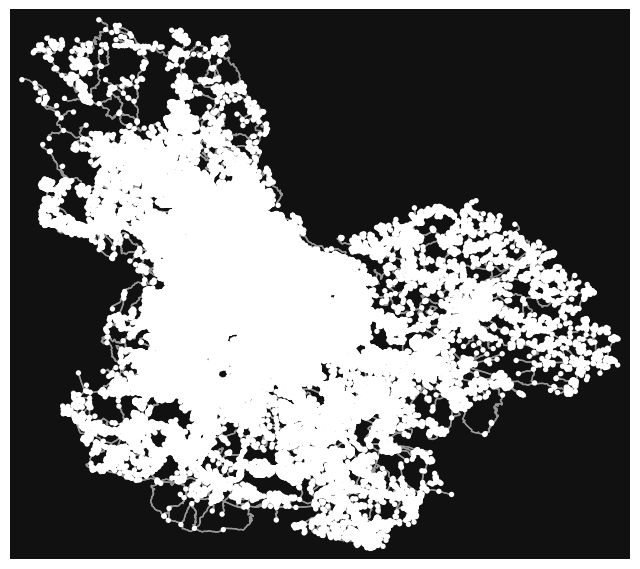

In [4]:
G_all = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    network_type="all",
    simplify=True,
    retain_all=False,
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_all)

In [ ]:
nodes_vial, edges_vial = ox.graph_to_gdfs(G_all, nodes=True, edges=True)

## __G_Railway (Tren Ligero)__

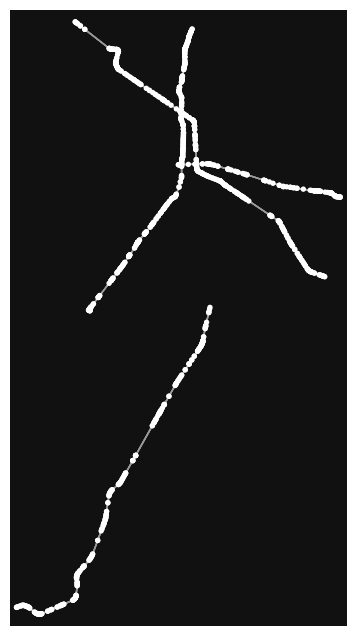

In [25]:
rail_filter = (
    '["railway"~"light_rail|subway|rail"]'
    '["name"~"Línea 1 del Tren Eléctrico Urbano|'
    'Linea 1 del Tren Eléctrico Urbano|'
    'Línea 2 del Tren Eléctrico Urbano|'
    'Linea 2 del Tren Eléctrico Urbano|'
    'Línea 3 del Tren Eléctrico Urbano|'
    'Linea 3 del Tren Eléctrico Urbano|'
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara|'
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara"]'
)

G_rail_uns = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    custom_filter=rail_filter,
    simplify=False, #AQUI si false para mantener todas las estaciones
    retain_all=True, #TRUE porque las 4 lineas no estan conectadas entre si
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_rail_uns)

In [26]:
nodes_rail, edges_rail = ox.graph_to_gdfs(G_rail_uns, nodes=True, edges=True)

## __Compose 2 graphs__

In [27]:
G_base = nx.compose(G_all, G_rail_uns)
nodes_base, edges_base = ox.graph_to_gdfs(G_base, nodes=True, edges=True)

## __Save Networks__

In [31]:
OUT_PATH = r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX'

# Red vial
save_gdf(nodes_vial, os.path.join(OUT_PATH, "Red Vial", "Nodes", "nodes_vial.shp"))
save_gdf(edges_vial, os.path.join(OUT_PATH, "Red Vial", "Edges", "edges_vial.shp"))

# Red ferroviaria
save_gdf(nodes_rail, os.path.join(OUT_PATH, "Red Tren Ligero", "Nodes", "nodes_rail.shp"))
save_gdf(edges_rail, os.path.join(OUT_PATH, "Red Tren Ligero", "Edges", "edges_rail.shp"))

# Red base (vial + ferroviaria)
save_gdf(nodes_base, os.path.join(OUT_PATH, "Red Base", "Nodes", "nodes_base.shp"))
save_gdf(edges_base, os.path.join(OUT_PATH, "Red Base", "Edges", "edges_base.shp"))

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Vial/Nodes/nodes_vial.shp
[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Vial/Edges/edges_vial.shp
[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Tren Ligero/Nodes/nodes_rail.shp
[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Tren Ligero/Edges/edges_rail.shp


/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base/Nodes/nodes_base.shp
[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base/Edges/edges_base.shp


## __Get only driveable edges for the snap part__

In [73]:
G_snap = G_base.copy()

valid_highways = {
    'motorway',
    'motorway_link',
    'trunk',
    'trunk_link',
    'primary',
    'primary_link',
    'secondary',
    'secondary_link',
    'tertiary',
    'tertiary_link',
    # some bus stops are on these types of links, so we keep them too
    # leave it like this for now, and later see if we add more types or if we can remove some 
    # Ideally we don't want to keep the small streets, as the nearest edge can snap to a small street instead of the main one,
    # BUT SOME STOP POINTS ARE ON SMALL STREETS
    'residential',
    'unclassified',
    #'service', #Maybe remove this ones
}

# Lista para guardar links a eliminar
edges_remove = []

# Recorrer todos los links
for u, v, k, data in G_snap.edges(keys=True, data=True):

    hwy = data.get("highway")

    # Caso highway es lista
    if isinstance(hwy, list):
        if not any(h in valid_highways for h in hwy):
            edges_remove.append((u, v, k))

    # Caso highway es texto
    elif isinstance(hwy, str):
        if hwy not in valid_highways:
            edges_remove.append((u, v, k))

    # Si no tiene atributo highway
    else:
        edges_remove.append((u, v, k))


In [74]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_snap.edge_subgraph(edges_remove),
    nodes=False
)
print(f"Edges a eliminar: {len(removed_edges)}")

counts = removed_edges["highway"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar: 160498
service 70243
living_street 48732
footway 20933
path 5984
cycleway 4180
track 3074
pedestrian 2743
steps 505
['footway', 'steps'] 310
busway 283
['footway', 'living_street'] 176
['steps', 'footway'] 168
corridor 150
['pedestrian', 'living_street'] 86
['path', 'living_street'] 66
['steps', 'corridor'] 50
['track', 'service'] 50
['footway', 'service'] 48
['path', 'service'] 44
['footway', 'pedestrian'] 38
['steps', 'pedestrian'] 32
bridleway 30
['path', 'track'] 30
['footway', 'cycleway'] 17
['service', 'pedestrian'] 14
['footway', 'path'] 11
['track', 'living_street'] 8
['steps', 'living_street'] 8
['service', 'living_street'] 8
['path', 'footway'] 7
['footway', 'steps', 'pedestrian'] 6
['steps', 'path'] 4
['path', 'steps'] 4
['steps', 'service'] 4
['steps', 'footway', 'pedestrian'] 4
['path', 'steps', 'footway'] 3
ladder 2
['footway', 'steps', 'path'] 2
['service', 'busway'] 2
['steps', 'service', 'footway'] 1
['footway', 'steps', 'service'] 1
['steps', 'path',

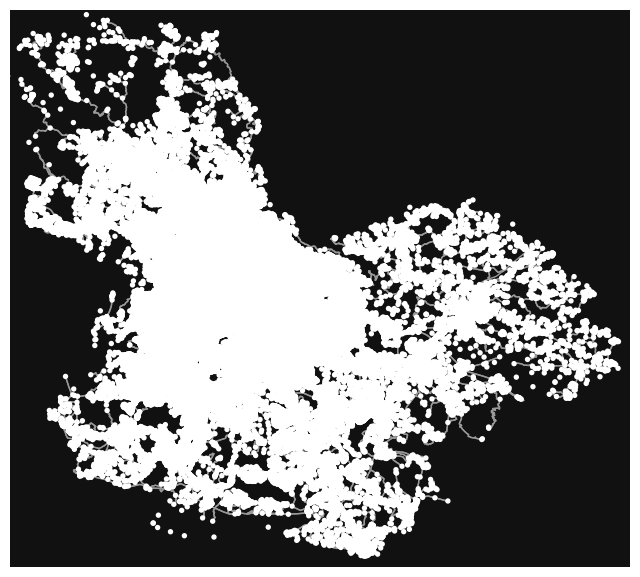

In [75]:
# Eliminar del grafo todos los links no válidos
G_snap.remove_edges_from(edges_remove)
fig, ax = ox.plot_graph(G_snap)

In [76]:
snap_nodes, snap_edges = ox.graph_to_gdfs(G_snap, nodes=True, edges=True)
save_gdf(snap_nodes, os.path.join(OUT_PATH, "Red Base Snap", "Nodes", "nodes_base_snap.shp"))
save_gdf(snap_edges, os.path.join(OUT_PATH, "Red Base Snap", "Edges", "edges_base_snap.shp"))

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Nodes/nodes_base_snap.shp
[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Edges/edges_base_snap.shp


## __Visum Nodes & Edges__

In [77]:
# NODES
visum_nodes = nodes_base.reset_index().copy()

visum_nodes["NodeNo"] = range(1, len(visum_nodes) + 1)
visum_nodes["XCoord"] = visum_nodes.geometry.x
visum_nodes["YCoord"] = visum_nodes.geometry.y

node_no_map = dict(zip(visum_nodes["osmid"], visum_nodes["NodeNo"]))


In [78]:
# EDGES
visum_links = edges_base.reset_index().copy()

# assign node numbers
visum_links["FromNodeNo"] = visum_links["u"].map(node_no_map)
visum_links["ToNodeNo"] = visum_links["v"].map(node_no_map)

visum_links["LinkNo"] = range(1, len(visum_links) + 1)
visum_links["Length_m"] = visum_links.to_crs(METRIC_CRS).length
visum_links["AllowedModes"] = visum_links.apply(classify_allowed_modes, axis=1) #later fix into real allowed modes
visum_links["OneWay"] = visum_links.apply(one_way_flag, axis=1)
visum_links["Name"] = visum_links.get("name", None).apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
)
visum_links

,u,v,key,osmid,highway,lanes,name,oneway,ref,reversed,...,width,service,area,FromNodeNo,ToNodeNo,LinkNo,Length_m,AllowedModes,OneWay,Name
0,267537966,7306651630,0,"[832652768, 619339782, 688424559, 188974544, 1...",motorway,"[2, 3]",Autopista Guadalajara - Morelia,True,MEX 15D;MEX 80D,False,...,NaN,NaN,NaN,1,103493,1,4832.636188,WALK,1,Autopista Guadalajara - Morelia
1,267537966,5837556433,0,694566994,motorway_link,1,NaN,True,NaN,False,...,NaN,NaN,NaN,1,15708,2,146.226523,WALK,1,NaN
2,267538751,273140976,0,189118222,motorway,2,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,NaN,NaN,NaN,2,3,3,520.548789,WALK,1,Autopista Guadalajara - Zapotlanejo
3,267538751,1746293763,0,907206852,motorway_link,1,Autopista Guadalajara - Morelia,True,MEX 15D,False,...,NaN,NaN,NaN,2,3068,4,617.879708,WALK,1,Autopista Guadalajara - Morelia
4,273140976,1997658287,0,835083267,motorway,3,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,NaN,NaN,NaN,3,7341,5,151.478387,WALK,1,Autopista Guadalajara - Zapotlanejo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494801,13656279161,5538433659,0,577828524,NaN,NaN,Linea 3 del Tren Eléctrico Urbano,False,NaN,False,...,NaN,NaN,NaN,206358,206163,494802,17.719509,WALK,0,Linea 3 del Tren Eléctrico Urbano
494802,13656279161,5538433658,0,577828524,NaN,NaN,Linea 3 del Tren Eléctrico Urbano,False,NaN,True,...,NaN,NaN,NaN,206358,206162,494803,20.002953,WALK,0,Linea 3 del Tren Eléctrico Urbano
494803,13705424642,4591349866,0,463965070,NaN,NaN,Línea 2 del Tren Eléctrico Urbano,False,NaN,False,...,NaN,yard,NaN,206359,206055,494804,49.828305,WALK,0,Línea 2 del Tren Eléctrico Urbano
494804,13705424642,4591553254,0,463965070,NaN,NaN,Línea 2 del Tren Eléctrico Urbano,False,NaN,True,...,NaN,yard,NaN,206359,206056,494805,1.844162,WALK,0,Línea 2 del Tren Eléctrico Urbano


In [79]:
save_gdf(visum_nodes, os.path.join(OUT_PATH, "Visum", "Nodes", "visum_nodes.shp"))
save_gdf(visum_links, os.path.join(OUT_PATH, "Visum", "Edges", "visum_links.shp"))

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Nodes/visum_nodes.shp
[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/visum_links.shp


/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'AllowedModes' to 'AllowedMod'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'OneWay' to 'OneWay_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Name' to 'Name_1'
  ogr_write(


## __Read BUS STOPS Imeplan__

In [80]:
stops_imeplan = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos IMEPLAN/Transporte Publico/amg_estategia_puntos_de_parada/AMG_estrategia_de_puntos_de_parada_de_transporte_publico_A04.shp')
stops_imeplan.head()

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,ruta_32,ruta_33,ruta_34,ruta_35,tipo,municipio,accion,etapa,dicts,geometry
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),El Salto,None,None,None,MULTIPOINT ((680976.456 2272736.641))
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Tonalá,None,None,None,MULTIPOINT ((681483.254 2280845.501))
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700561.553 2281164.022))
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700707.084 2281320.114))
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700907.289 2281378.235))


In [81]:
print("original stops_imeplan CRS:", stops_imeplan.crs)
stops_imeplan = stops_imeplan.to_crs(epsg=4326)
print("stops_imeplan CRS after transformation:", stops_imeplan.crs)

original stops_imeplan CRS: EPSG:32613
stops_imeplan CRS after transformation: EPSG:4326


## __SNAP Bus Stops to Link__

In [82]:
# 1) Copia y revisa tipos geométricos
bus_stops = stops_imeplan.copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 2) Convierte MultiPoint -> Point (una fila por punto)
bus_stops = bus_stops.explode(index_parts=False).reset_index(drop=True)
print(bus_stops.geom_type.value_counts(dropna=False))

# 3) Quédate solo con Point válidos
bus_stops = bus_stops[bus_stops.geometry.notna() & (bus_stops.geom_type == "Point")].copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 4) Extrae coordenadas
bus_stops["XCoord"] = bus_stops.geometry.x
bus_stops["YCoord"] = bus_stops.geometry.y
print(bus_stops[["XCoord", "YCoord"]].head())

MultiPoint    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
       XCoord     YCoord
0 -103.264060  20.544832
1 -103.258369  20.618022
2 -103.075320  20.618956
3 -103.073906  20.620351
4 -103.071979  20.620854


In [83]:
# 5) Encuentra nodos más cercanos
nearest_nodes = ox.nearest_nodes(G_snap, bus_stops["XCoord"], bus_stops["YCoord"])

# 6) Encuentra edges más cercanas y distancias
nearest_edges, edge_distance = ox.nearest_edges(
    G_snap, X=bus_stops["XCoord"], Y=bus_stops["YCoord"], return_dist=True
)

bus_stops["NearestNodeOSM"] = nearest_nodes
bus_stops["NearestNodeNo"] = bus_stops["NearestNodeOSM"].map(node_no_map)
bus_stops["NearestEdge"] = list(nearest_edges) # nearest edge in (u,v,key) format (tupla)
bus_stops["SnapDist_m"] = edge_distance

In [84]:
# derive nearest link and relative position
nearest_link_nos = []
rel_positions = []
from_node_nos = []
to_node_nos = []

visum_links_geom = visum_links[["LinkNo", "u", "v", "key", "FromNodeNo", "ToNodeNo", "geometry"]].copy()
visum_links_geom = visum_links_geom.set_index(["u", "v", "key"])

for row in bus_stops.itertuples():
    e = row.NearestEdge
    if e in visum_links_geom.index:
        rec = visum_links_geom.loc[e]
        line = rec.geometry
        p = row.geometry

        # relative position on directional link
        rel = 0.0
        try:
            line_m = gpd.GeoSeries([line], crs=WGS84).to_crs(METRIC_CRS).iloc[0]
            p_m = gpd.GeoSeries([p], crs=WGS84).to_crs(METRIC_CRS).iloc[0]
            if line_m.length > 0:
                rel = float(line_m.project(p_m) / line_m.length)
        except Exception:
            rel = 0.0

        nearest_link_nos.append(int(rec.LinkNo))
        rel_positions.append(rel)
        from_node_nos.append(int(rec.FromNodeNo))
        to_node_nos.append(int(rec.ToNodeNo))
    else:
        nearest_link_nos.append(None)
        rel_positions.append(None)
        from_node_nos.append(None)
        to_node_nos.append(None)

bus_stops["NearestLinkNo"] = nearest_link_nos
bus_stops["RelPosOnLink"] = rel_positions
bus_stops["FromNodeNo"] = from_node_nos
bus_stops["ToNodeNo"] = to_node_nos

In [85]:
bus_stops
save_gdf(bus_stops, os.path.join(OUT_PATH, "Transporte Publico", "Stop Points", "bus_stops_snapped.shp"))

[OK] Saved: /Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Stop Points/bus_stops_snapped.shp


/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeOSM' to 'NearestNod'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeNo' to 'NearestN_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestEdge' to 'NearestEdg'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLinkNo' to 'NearestLin'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'RelPosOnLink' to 'RelPosOnLi'
  ogr_write(
